In [7]:
import pandas as pd
import seaborn as sns                                                                                     
import matplotlib.pyplot as plt

In [8]:
sns.set_theme(style="darkgrid")
sns.set_palette("rocket_r")

In [9]:
results = pd.read_csv("/Users/ochsneto/Documents/BDMM/BDMM-Flow/results.csv")
results.describe()

,node_count,leaf_count,types_count,process_length,flow_likelihood,flow_duration,bdmm_likelihood,bdmm_duration,num_intervals
count,90006.000000,90006.000000,90006.000000,90006.000000,89510.000000,9.000600e+04,90006.000000,9.000600e+04,90006.000000
mean,117.008133,59.004066,5.991867,2.988258,-418.693310,8.988660e+05,-422.507580,2.718117e+06,2.495900
std,1346.652463,673.326231,2.571011,1.143378,6607.244449,2.173066e+06,6611.614735,1.423743e+07,1.500003
min,3.000000,2.000000,2.000000,1.000063,-628331.480857,1.487500e+04,-629888.370022,2.695800e+04,1.000000
25%,5.000000,3.000000,4.000000,2.001114,-86.173496,1.294582e+05,-88.205077,1.548330e+05,1.000000
50%,11.000000,6.000000,6.000000,2.978631,-19.711858,3.202080e+05,-20.423970,3.786250e+05,1.000000
75%,39.000000,20.000000,8.000000,3.965003,-8.138999,8.777808e+05,-8.520215,1.259917e+06,4.000000
max,122783.000000,61392.000000,10.000000,4.999880,0.412177,2.532962e+08,-0.482295,9.685411e+08,4.000000


In [10]:
results = results[results["leaf_count"] > 10]
results["speedup"] = results["bdmm_duration"] / results["flow_duration"]
results["binned_leaves"] = results["leaf_count"].apply(lambda x: x // 200 * 200)

In [11]:
identity = results[results["initial_state_strategy"] == "identity"]
random = results[results["initial_state_strategy"] == "random"]
error_heuristic = results[results["initial_state_strategy"] == "error_heuristic"]
probe_heuristic = results[results["initial_state_strategy"] == "probe_heuristic"]
taylor_heuristic = results[results["initial_state_strategy"] == "taylor_heuristic"]
taylor_exp_heuristic = results[results["initial_state_strategy"] == "taylor_exp_heuristic"]

In [12]:
ax = sns.barplot(data=pd.DataFrame({    
    "Method": [
        "Identity", 
        "Random", 
        "Error Heuristic",
        "Probe Heuristic",
        "Taylor Heuristic",
        "Taylor Exp Heuristic",
    ],
    "Num Integration Steps": [
        identity["flow_num_steps"].median(),
        random["flow_num_steps"].median(),
        error_heuristic["flow_num_steps"].median(),
        probe_heuristic["flow_num_steps"].median(),
        taylor_heuristic["flow_num_steps"].median(),
        taylor_exp_heuristic["flow_num_steps"].median(),
    ]
}), x="Method", y="Num Integration Steps")
plt.xticks(rotation=45)
for i in ax.containers:
    ax.bar_label(i,)

KeyError: 'flow_num_steps'

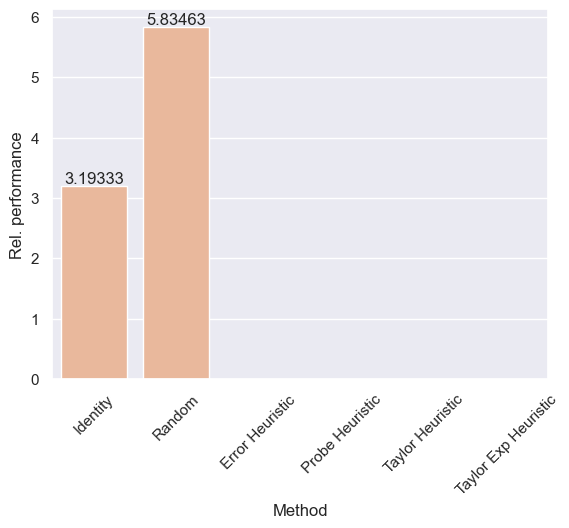

In [13]:
ax = sns.barplot(data=pd.DataFrame({
    "Method": [
        "Identity", 
        "Random", 
        "Error Heuristic",
        "Probe Heuristic",
        "Taylor Heuristic",
        "Taylor Exp Heuristic",
    ],
    "Rel. performance": [
        identity["speedup"].median(),
        random["speedup"].median(),
        error_heuristic["speedup"].median(),
        probe_heuristic["speedup"].median(),
        taylor_heuristic["speedup"].median(),
        taylor_exp_heuristic["speedup"].median(),
    ]
}), x="Method", y="Rel. performance", errorbar="pi")
plt.xticks(rotation=45)
for i in ax.containers:
    ax.bar_label(i,)

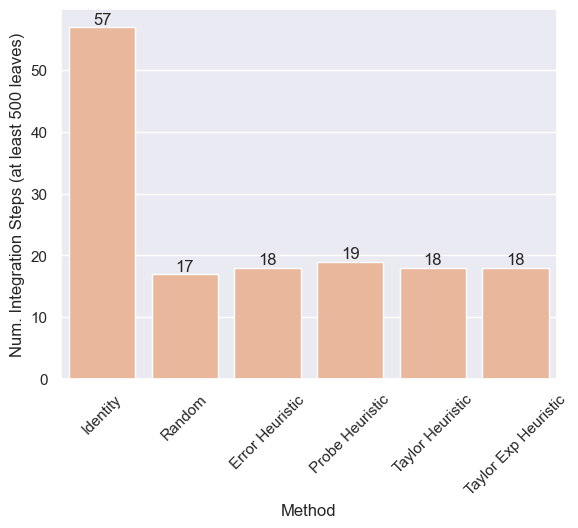

In [ ]:
ax = sns.barplot(data=pd.DataFrame({
    "Method": [
        "Identity", 
        "Random", 
        "Error Heuristic",
        "Probe Heuristic",
        "Taylor Heuristic",
        "Taylor Exp Heuristic",
    ],
    "Num. Integration Steps (at least 500 leaves)": [
        identity[identity["leaf_count"] > 500]["flow_num_steps"].median(),
        random[random["leaf_count"] > 500]["flow_num_steps"].median(),
        error_heuristic[error_heuristic["leaf_count"] > 500]["flow_num_steps"].median(),
        probe_heuristic[probe_heuristic["leaf_count"] > 500]["flow_num_steps"].median(),
        taylor_heuristic[taylor_heuristic["leaf_count"] > 500]["flow_num_steps"].median(),
        taylor_exp_heuristic[taylor_exp_heuristic["leaf_count"] > 500]["flow_num_steps"].median(),
    ]
}), x="Method", y="Num. Integration Steps (at least 500 leaves)")

plt.xticks(rotation=45)

for i in ax.containers:
    ax.bar_label(i,)

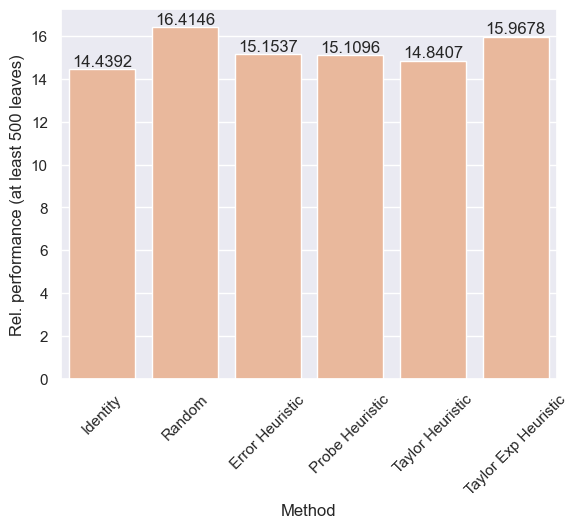

In [ ]:
ax = sns.barplot(data=pd.DataFrame({
    "Method": [
        "Identity", 
        "Random", 
        "Error Heuristic",
        "Probe Heuristic",
        "Taylor Heuristic",
        "Taylor Exp Heuristic",
    ],
    "Rel. performance (at least 500 leaves)": [
        identity[identity["leaf_count"] > 500]["speedup"].median(),
        random[random["leaf_count"] > 500]["speedup"].median(),
        error_heuristic[error_heuristic["leaf_count"] > 500]["speedup"].median(),
        probe_heuristic[probe_heuristic["leaf_count"] > 500]["speedup"].median(),
        taylor_heuristic[taylor_heuristic["leaf_count"] > 500]["speedup"].median(),
        taylor_exp_heuristic[taylor_exp_heuristic["leaf_count"] > 500]["speedup"].median(),
    ]
}), x="Method", y="Rel. performance (at least 500 leaves)")

plt.xticks(rotation=45)

for i in ax.containers:
    ax.bar_label(i,)

Text(0, 0.5, 'BDMM Log Likelihood')

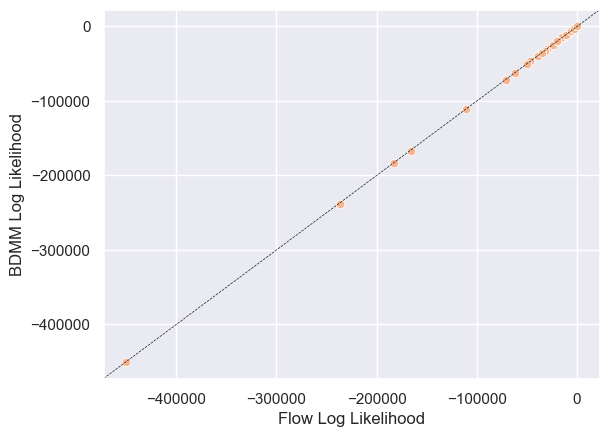

In [ ]:
ax = sns.scatterplot(results, x="flow_likelihood", y="bdmm_likelihood")
ax.plot(ax.get_xlim(), ax.get_xlim(), linestyle='--', color='k', lw=0.5, scalex=False, scaley=False)

plt.xlabel('Flow Log Likelihood')
plt.ylabel('BDMM Log Likelihood')

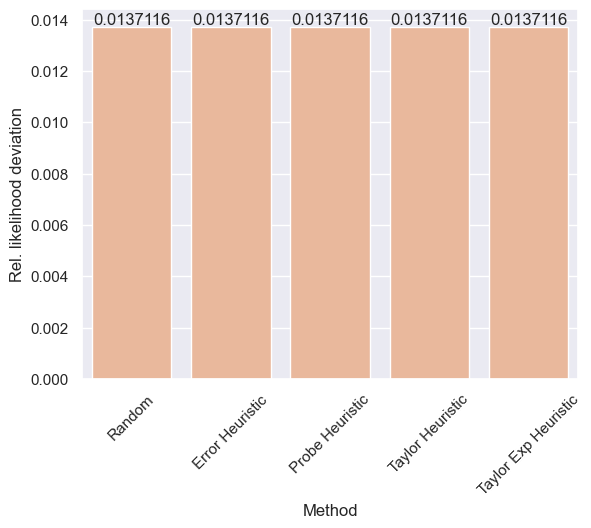

In [ ]:
ax = sns.barplot(data=pd.DataFrame({
    "Method": [
        "Random", 
        "Error Heuristic",
        "Probe Heuristic",
        "Taylor Heuristic",
        "Taylor Exp Heuristic",
    ],
    "Rel. likelihood deviation": [
        ((random["bdmm_likelihood"] - random["flow_likelihood"]) / random["bdmm_likelihood"]).abs().mean(),
        ((error_heuristic["bdmm_likelihood"] - error_heuristic["flow_likelihood"]) / error_heuristic["bdmm_likelihood"]).abs().mean(),
        ((probe_heuristic["bdmm_likelihood"] - probe_heuristic["flow_likelihood"]) / probe_heuristic["bdmm_likelihood"]).abs().mean(), 
        ((taylor_heuristic["bdmm_likelihood"] - taylor_heuristic["flow_likelihood"]) / taylor_heuristic["bdmm_likelihood"]).abs().mean(), 
        ((taylor_exp_heuristic["bdmm_likelihood"] - taylor_exp_heuristic["flow_likelihood"]) / taylor_exp_heuristic["bdmm_likelihood"]).abs().mean(), 
    ]
}), x="Method", y="Rel. likelihood deviation")

plt.xticks(rotation=45)

for i in ax.containers:
    ax.bar_label(i,)

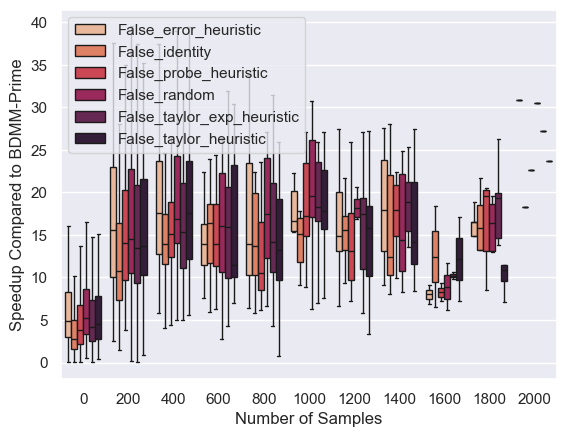

In [ ]:
relevant_results = results

relevant_results["algorithm"] = relevant_results.apply(lambda row: f'{row["use_inverse_flow"]}_{row["initial_state_strategy"]}', axis=1)
relevant_results = relevant_results.sort_values(by="algorithm")

ax = sns.boxplot(
    relevant_results[(relevant_results.binned_leaves < 2200)],
    x="binned_leaves", y="speedup", hue="algorithm",
    showfliers=False
)

ax.legend_.set_title(None)
# ax.legend_.texts[0].set_text("No Extension")
# ax.legend_.texts[1].set_text("Random Initial Matrix")
# ax.legend_.texts[2].set_text("Random Initial Matrix + Inverse Flow")

plt.xlabel('Number of Samples')
plt.ylabel('Speedup Compared to BDMM-Prime')

plt.savefig("speedup_vs_sample_count.png", bbox_inches="tight", dpi=600)

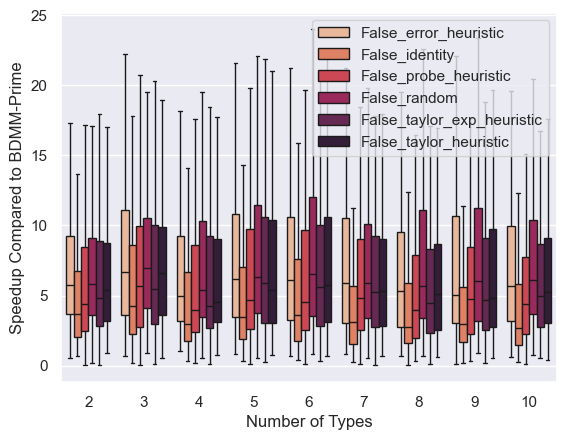

In [ ]:
ax = sns.boxplot(
    relevant_results,
    x="types_count", y="speedup", hue="algorithm",
    showfliers=False
)

ax.legend_.set_title(None)
# ax.legend_.texts[0].set_text("No Extension")
# ax.legend_.texts[1].set_text("Random Initial Matrix")
# ax.legend_.texts[2].set_text("Random Initial Matrix + Inverse Flow")

plt.xlabel('Number of Types')
plt.ylabel('Speedup Compared to BDMM-Prime')

plt.savefig("speedup_vs_type_count.png", bbox_inches="tight", dpi=600)